In [4]:
from custom_components.discrete_state_forecaster.model.learning.drift_monitor import DriftMonitor

monitor = DriftMonitor(
    slow_half_life=3600 * 24,
    fast_half_life=3600.0 * 2,
    drift_half_life=3600 * 24 * 1.5,
    n_enter=1,
    n_exit=1,
)

dist = {"A": 0.7, "B": 0.2, "C": 0.1}
for i in range(12):
    monitor.update(
        dist=dist,
        timestamp=3600.0 * i,
    )

# monitor.update(
#     dist={"ok": 0.8, "warn": 0.2},
#     support_time=300.0,
#     timestamp=3600.0*6,
# )
# monitor.update(
#     dist={"ok": 0.1, "warn": 0.8, "error": 0.1},
#     support_time=3600.0,
#     timestamp=3600.0*24,
# )

# monitor.update(
#     dist={"ok": 0.01, "warn": 0.5, "error": 0.49},
#     support_time=3600.0*10,
#     timestamp=3600.0*2,
# )

dist = {"A": 0.05, "B": 0.05, "C": 0.9}
monitor.update(
    dist=dist,
    timestamp=3600.0 * 320,
)

dist = {"A": 0.00, "B": 0.01, "C": 0.99}
monitor.update(
    dist=dist,
    timestamp=3600.0 * 330,
)

dist = {"A": 0.1, "B": 0.4, "C": 0.5}
monitor.update(
    dist=dist,
    timestamp=3600.0 * 333,
)
# dist = {"A": 0.05, "B": 0.05, "C": 0.9}
# monitor.update(
#     dist=dist,
#     timestamp=3600.0 * 520,
# )

print(monitor._slow_baseline.distribution())
print(monitor._fast_baseline.distribution())
print(monitor.last_drift)
print(monitor.is_drifting)
print(monitor._tau_enter)
print(monitor._tau_exit)

# print(js_divergence(monitor.slow.get_distribution(), monitor.fast.get_distribution()))

{'A': 0.04862803221118359, 'B': 0.0530445061923195, 'C': 0.8983274615964969}
{'A': 0.04730874875712244, 'B': 0.14131871492027093, 'C': 0.8113725363226068}
0.01660564958596901
True
0.014332445141120812
0.008024267005292907


In [127]:
print(monitor.drift_stats.mean)
print(monitor.drift_stats.std)

0.20179452917925167
0.20997451378875914


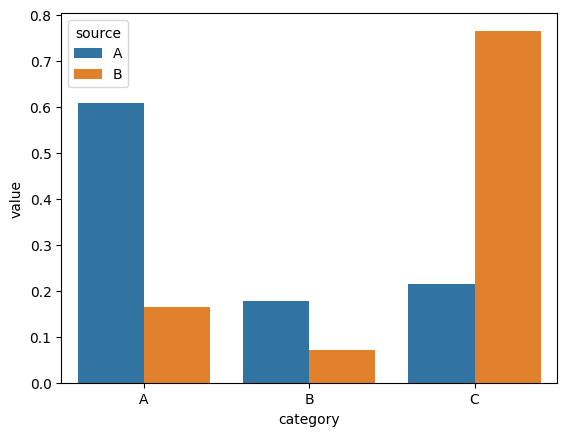

0.024142960150032797


In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

data_a = monitor.slow.get_distribution()
data_b = monitor.fast.get_distribution()

import pandas as pd

df = pd.concat(
    [
        pd.DataFrame(data_a.items(), columns=["category", "value"]).assign(source="A"),
        pd.DataFrame(data_b.items(), columns=["category", "value"]).assign(source="B"),
    ]
)


sns.barplot(data=df, x="category", y="value", hue="source")
plt.show()


print(js)